# load libraries

In [1]:
import re
import os
import random
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [2]:
language_mapping = {
    "as.txt": "Assamese",
    "bd.txt": "Bodo",
    "bn.txt": "Bengali",
    "dg.txt": "Dogri",
    "en.txt": "English",
    "gom.txt": "Goan Konkani",
    "gu.txt": "Gujarati",
    "hi.txt": "Hindi",
    "kha.txt": "Khasi",
    "kn.txt": "Kannada",
    "ks.txt": "Kashmiri",
    "mai.txt": "Maithili",
    "ml.txt": "Malayalam",
    "mni.txt": "Manipuri (Meitei)",
    "mr.txt": "Marathi",
    "ne.txt": "Nepali",
    "or.txt": "Odia",
    "pa.txt": "Punjabi",
    "sa.txt": "Sanskrit",
    "sat.txt": "Santali",
    "sd.txt": "Sindhi",
    "ta.txt": "Tamil",
    "te.txt": "Telugu",
    "ur.txt": "Urdu"
}

In [3]:
input_folder = r"D:/LLM/LAB 1/Dataset/raw_data"
tokenized_data = r"D:/LLM/LAB 1/Dataset/tokenized_data"
train_data=r"D:/LLM/LAB 1/Dataset/train"
test_data=r"D:/LLM/LAB 1/Dataset/test"
val_data=r"D:/LLM/LAB 1/Dataset/val"

# tokenization

In [4]:
SENTENCE_PATTERN = r'(?<=[.!?।۔؟])\s+'

In [5]:
def sentence_tokenization(text, output_file):
    sentences = re.split(r'(?<=[.!?।۔؟])\s+', text)

    lines=0

    with open(output_file, 'w', encoding="utf-8") as f:
        for sent in sentences:
            sent = re.sub(r'\s+', ' ', sent).strip()

            if sent and lines<1000:
                lines=lines+1
                f.write(sent + "\n")

In [6]:
for filename, language in language_mapping.items():

    filepath = os.path.join(input_folder, filename)

    print(f"Processing {filename} ({language})")

    try:
        with open(filepath, "r", encoding="utf-8", errors="replace") as f:
            text = f.read()

    except Exception as e:
        print(f"Failed reading {filename}: {e}")
        continue

    output_file = os.path.join(
        tokenized_data,
        filename
    )

    sentence_tokenization(text, output_file)

Processing as.txt (Assamese)
Processing bd.txt (Bodo)
Processing bn.txt (Bengali)
Processing dg.txt (Dogri)
Processing en.txt (English)
Processing gom.txt (Goan Konkani)
Processing gu.txt (Gujarati)
Processing hi.txt (Hindi)
Processing kha.txt (Khasi)
Processing kn.txt (Kannada)
Processing ks.txt (Kashmiri)
Processing mai.txt (Maithili)
Processing ml.txt (Malayalam)
Processing mni.txt (Manipuri (Meitei))
Processing mr.txt (Marathi)
Processing ne.txt (Nepali)
Processing or.txt (Odia)
Processing pa.txt (Punjabi)
Processing sa.txt (Sanskrit)
Processing sat.txt (Santali)
Processing sd.txt (Sindhi)
Processing ta.txt (Tamil)
Processing te.txt (Telugu)
Processing ur.txt (Urdu)


# slpit

In [7]:
for filename, language in language_mapping.items():

    input_file=os.path.join(tokenized_data, filename)
    train_file=os.path.join(train_data, filename)
    val_file=os.path.join(val_data, filename)
    test_file=os.path.join(test_data, filename)

    with open(input_file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    random.shuffle(lines)

    total = len(lines)
    train_size = int(0.8 * total)
    val_size = int(0.1 * total)

    # Create splits
    train_lines = lines[:train_size]
    val_lines = lines[train_size:train_size + val_size]
    test_lines = lines[train_size + val_size:]

    with open(train_file, "w", encoding="utf-8") as f:
        f.writelines(train_lines)

    with open(val_file, "w", encoding="utf-8") as f:
        f.writelines(val_lines)

    with open(test_file, "w", encoding="utf-8") as f:
        f.writelines(test_lines)

combine to final train,test,val csv files


In [8]:
folders=[val_data,test_data,train_data]

for folder_path in folders:

    data = []

    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):

            file_path = os.path.join(folder_path, filename)

            with open(file_path, "r", encoding="utf-8") as f:
                for line in f:
                    data.append({
                        "text": line.strip(),
                        "language": language_mapping[filename]
                    })

    df = pd.DataFrame(data)
    df = df.sample(frac=1).reset_index(drop=True)

    
    df.to_csv(folder_path+"_combined.csv", index=False, encoding="utf-8")

In [9]:

train_df = pd.read_csv("D:/LLM/LAB 1/Dataset/train_combined.csv")
test_df = pd.read_csv("D:/LLM/LAB 1/Dataset/test_combined.csv")
val_df = pd.read_csv("D:/LLM/LAB 1/Dataset/val_combined.csv")
full_df = pd.concat([train_df, test_df, val_df], ignore_index=True)

# vocab and frequency analysis (word level)

In [10]:
globle_vocab=set()
language_vocab={}
language_vocab_freq={}
globle_vocab_freq={}

In [11]:
def vocab(text):
    v=set()

    for line in text:
        w=str(line).lower().split()
        v.update(w)

    return v

def build_frequency(text,freq=None):

    if freq is None:
        freq = {}

    for w in text:
        for line in text:
            words=str(line).lower().split()

            for w in words:
                freq[w] = freq.get(w, 0) + 1

    return freq

In [12]:
for filename, language in language_mapping.items():

    v=vocab(full_df.loc[full_df["language"]==language,'text'])
    globle_vocab.update(v)
    language_vocab[language]=v
    
    globle_vocab_freq=build_frequency(full_df.loc[full_df["language"]==language,'text'],globle_vocab_freq)
    language_vocab_freq[language]=build_frequency(full_df.loc[full_df["language"]==language,'text'])

{'Assamese': 9550, 'Bodo': 8222, 'Bengali': 6294, 'Dogri': 7482, 'English': 7464, 'Goan Konkani': 6820, 'Gujarati': 7477, 'Hindi': 5377, 'Khasi': 8387, 'Kannada': 7774, 'Kashmiri': 5221, 'Maithili': 6987, 'Malayalam': 6886, 'Manipuri (Meitei)': 14228, 'Marathi': 6747, 'Nepali': 6925, 'Odia': 4549, 'Punjabi': 6748, 'Sanskrit': 4183, 'Santali': 19048, 'Sindhi': 6570, 'Tamil': 7349, 'Telugu': 6033, 'Urdu': 8337}


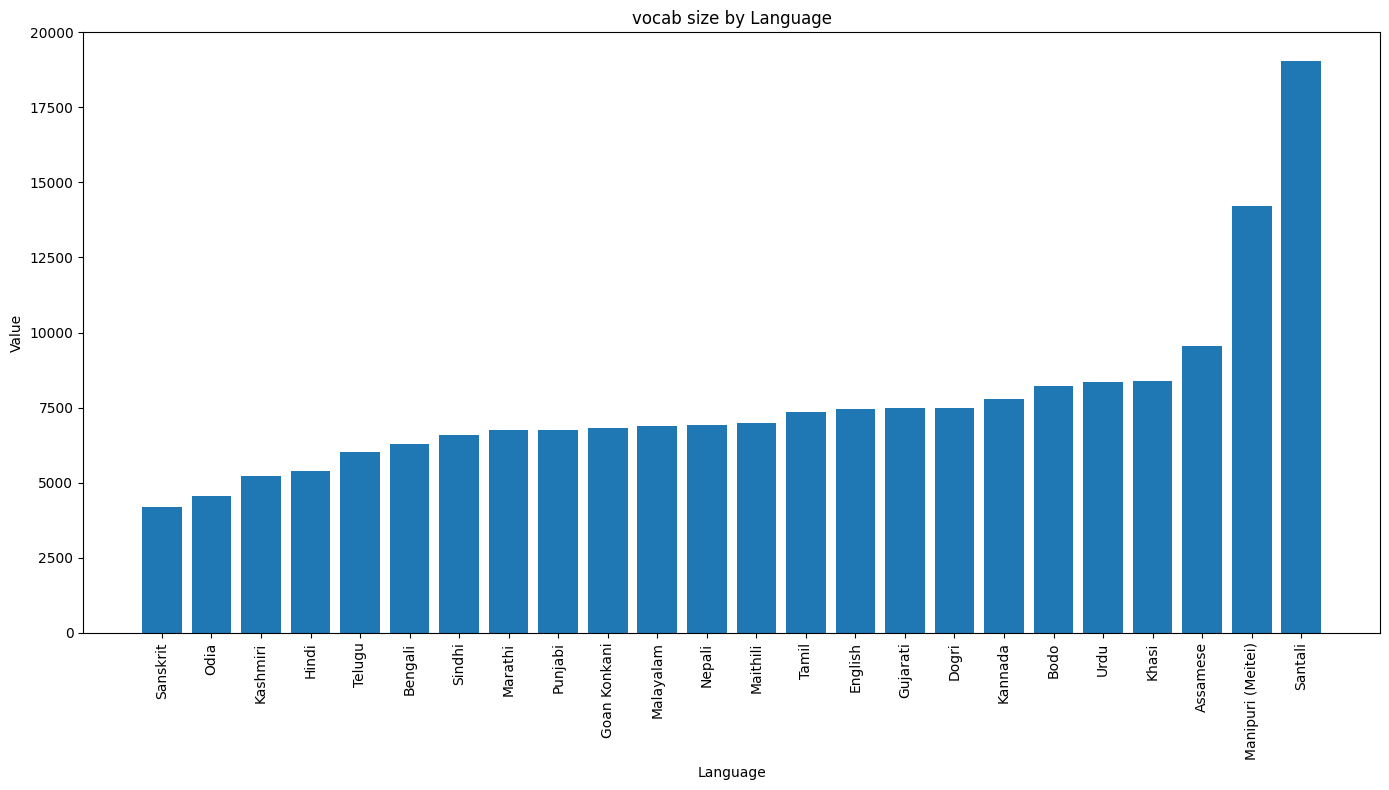

In [13]:
language_vocab_size={}

for language in language_vocab:
    language_vocab_size[language]=len(language_vocab[language])

print(language_vocab_size)


data_sorted = dict(sorted(language_vocab_size.items(), key=lambda x: x[1]))
plt.figure(figsize=(14, 8))

plt.bar(data_sorted.keys(), data_sorted.values())

plt.xlabel("Language")
plt.ylabel("Value")
plt.title("vocab size by Language")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

{'Assamese': 21958000, 'Bodo': 20020000, 'Bengali': 12975000, 'Dogri': 24219000, 'English': 20322000, 'Goan Konkani': 11829000, 'Gujarati': 16820000, 'Hindi': 19316000, 'Khasi': 29408000, 'Kannada': 12101000, 'Kashmiri': 13649000, 'Maithili': 15060000, 'Malayalam': 9313000, 'Manipuri (Meitei)': 77938000, 'Marathi': 12987000, 'Nepali': 15299000, 'Odia': 17699000, 'Punjabi': 23978000, 'Sanskrit': 5676000, 'Santali': 89635000, 'Sindhi': 22979000, 'Tamil': 11382000, 'Telugu': 9878000, 'Urdu': 37046000}


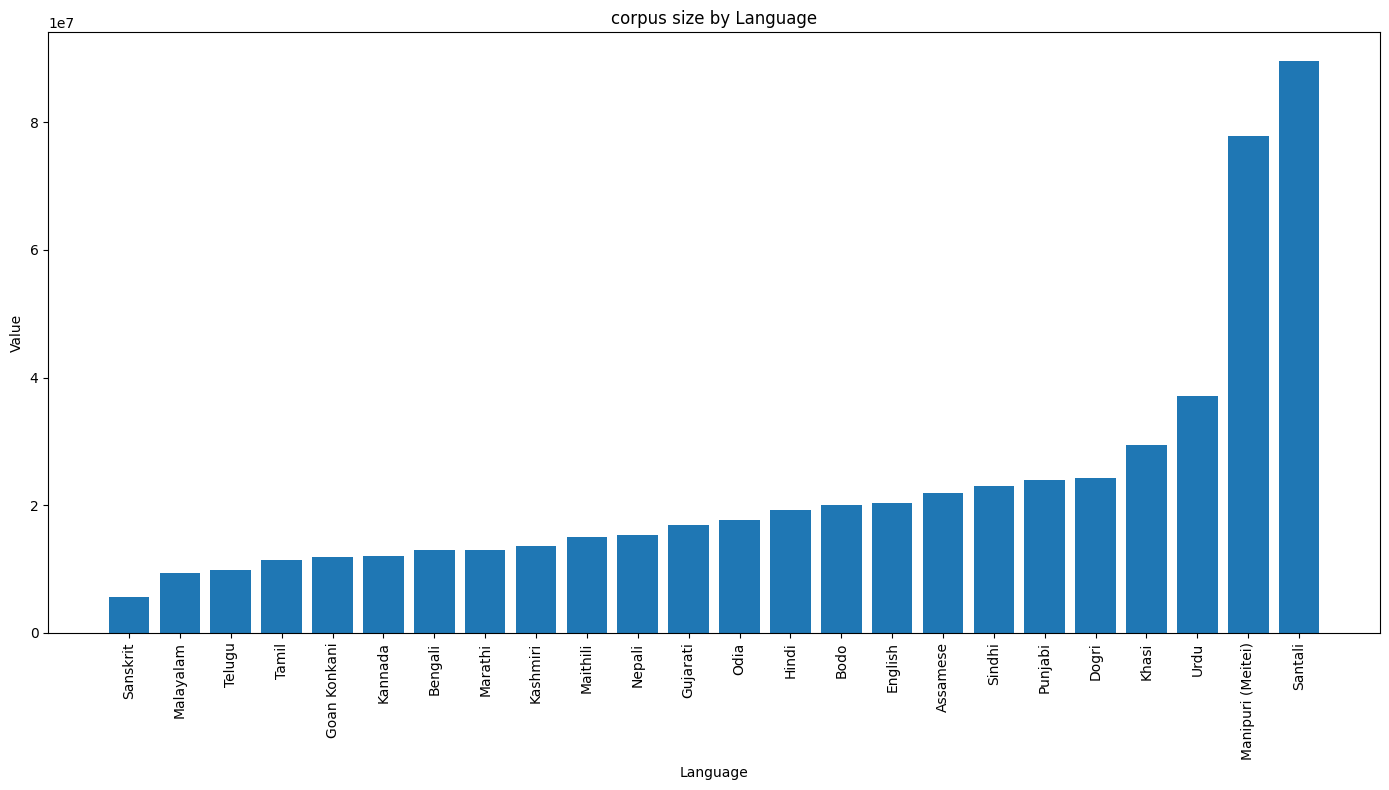

In [14]:
corpus_size={}

for language,freqs in language_vocab_freq.items():
    corpus_size[language]=sum(freqs.values())


print(corpus_size)

data_sorted = dict(sorted(corpus_size.items(), key=lambda x: x[1]))
plt.figure(figsize=(14, 8))

plt.bar(data_sorted.keys(), data_sorted.values())

plt.xlabel("Language")
plt.ylabel("Value")
plt.title("corpus size by Language")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

{'Assamese': 0.03981598840951826, 'Bodo': 0.036301852990188344, 'Bengali': 0.023527299827557132, 'Dogri': 0.043915813065403174, 'English': 0.03684946335997041, 'Goan Konkani': 0.02144928166937752, 'Gujarati': 0.030499359005742657, 'Hindi': 0.03502530431361029, 'Khasi': 0.053324919717055885, 'Kannada': 0.021942493658055402, 'Kashmiri': 0.024749450123031005, 'Maithili': 0.027307987314297528, 'Malayalam': 0.016887070774107095, 'Manipuri (Meitei)': 0.14132336754991504, 'Marathi': 0.023549059179998805, 'Nepali': 0.027741361083760813, 'Odia': 0.03209323157209508, 'Punjabi': 0.043478812737199606, 'Sanskrit': 0.010292173704910541, 'Santali': 0.16253329634243419, 'Sindhi': 0.041667346646430466, 'Tamil': 0.020638745790925263, 'Telugu': 0.01791157361823579, 'Urdu': 0.06717474754617969}


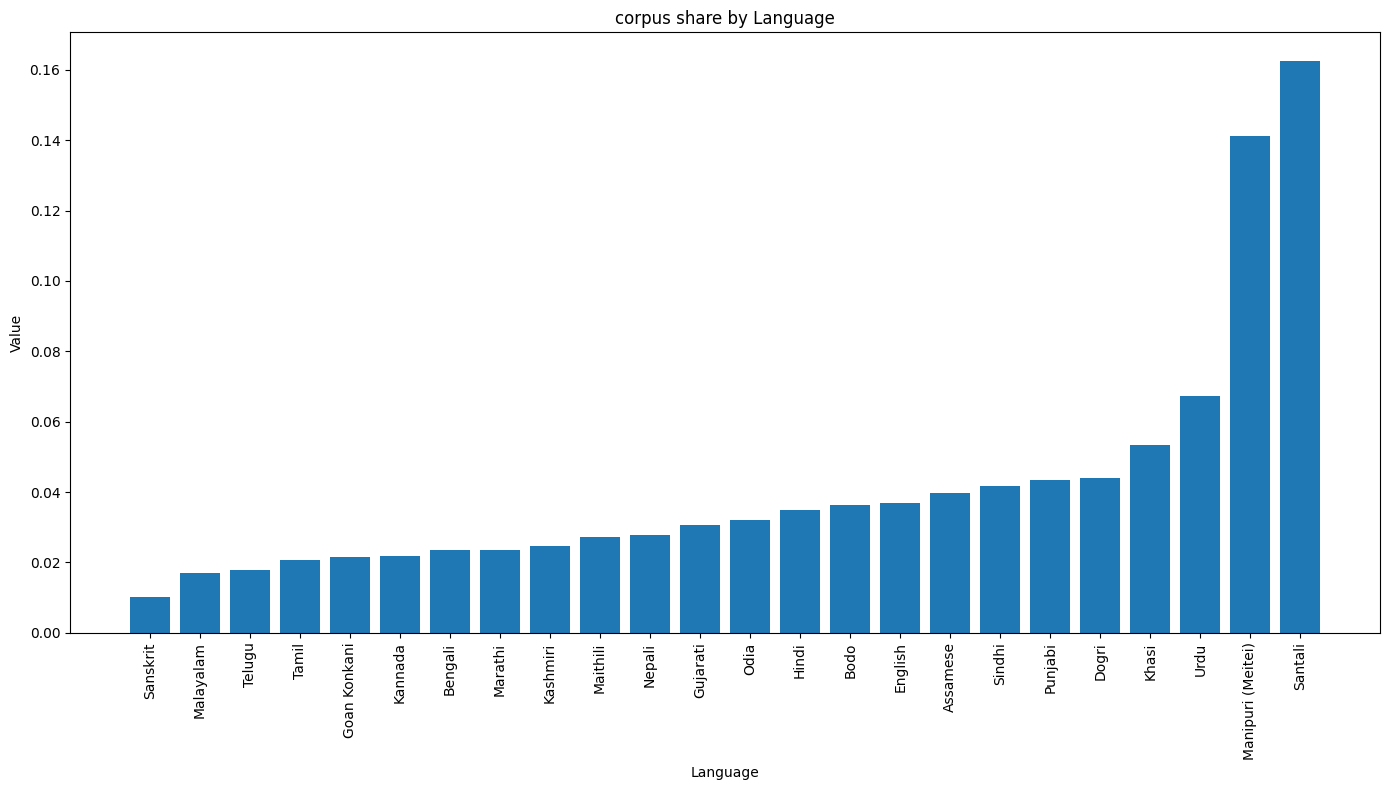

In [15]:
corpus_share={}
total=sum(corpus_size.values())

for language,size in corpus_size.items():
    corpus_share[language]=size/total

print(corpus_share)

data_sorted = dict(sorted(corpus_share.items(), key=lambda x: x[1]))
plt.figure(figsize=(14, 8))

plt.bar(data_sorted.keys(), data_sorted.values())

plt.xlabel("Language")
plt.ylabel("Value")
plt.title("corpus share by Language")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [16]:
with open("D:/LLM/LAB 1/Dataset/globle_vocab.pkl", "wb") as file:
    pickle.dump(globle_vocab, file)

with open("D:/LLM/LAB 1/Dataset/language_vocab.pkl", "wb") as file:
    pickle.dump(language_vocab, file)

with open("D:/LLM/LAB 1/Dataset/language_vocab_freq.pkl", "wb") as file:
    pickle.dump(language_vocab_freq, file)

with open("D:/LLM/LAB 1/Dataset/globle_vocab_freq.pkl", "wb") as file:
    pickle.dump(globle_vocab_freq, file)

with open("D:/LLM/LAB 1/Dataset/language_vocab_size.pkl", "wb") as file:
    pickle.dump(language_vocab_size, file)

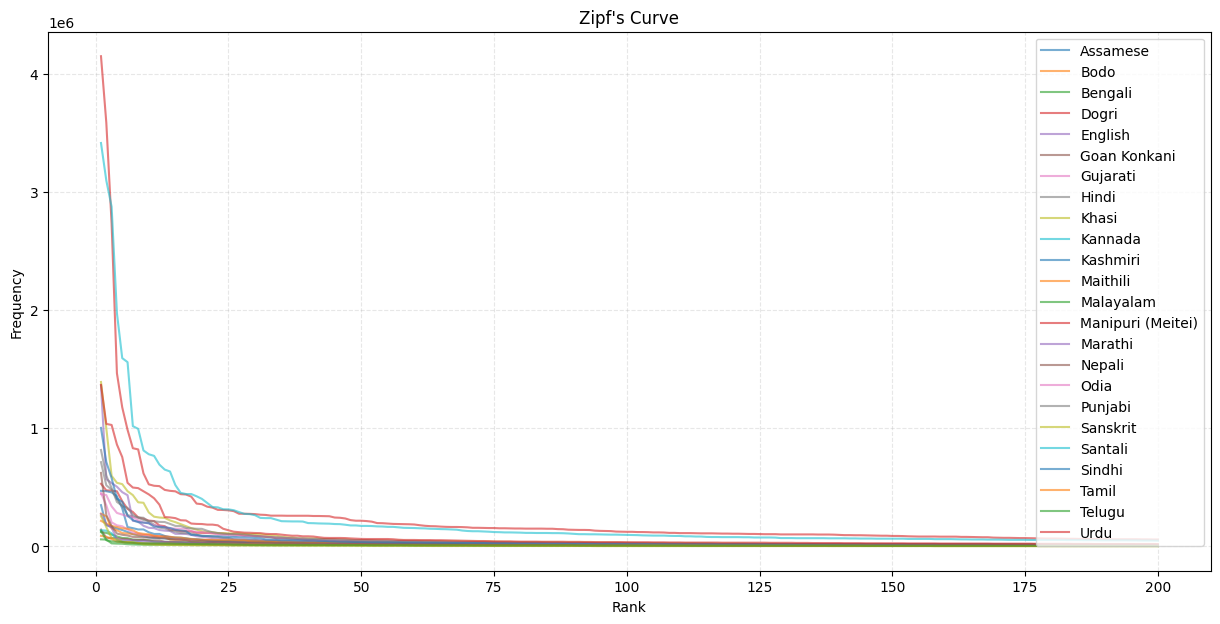

In [17]:
plt.figure(figsize=(15, 7))

for language, word_freq in language_vocab_freq.items():
    sorted_freq = sorted(word_freq.values(), reverse=True)[:200]

    ranks = range(1, len(sorted_freq) + 1)

    plt.plot(
        ranks,
        sorted_freq,
        label=language,
        alpha=0.6
    )

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Curve")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.show()

# working with stop words

In [18]:
def top_k(freq, k=100):
    return sorted(freq.items(), key=lambda x: (-x[1], x[0]))[:k]

def remove_stopwords(freq, threshold):
    if not freq:
        print("Warning: freq is empty, skipping stopword removal")
        return {}, threshold

    counts = sorted(freq.values())
    
    if isinstance(threshold, float) and 0 < threshold <= 1:
        idx = int(round((len(counts) - 1) * threshold))
        T = counts[idx]
    else:
        T = int(threshold)
    cleaned = {w: c for w, c in freq.items() if c > T}
    return cleaned, T



In [19]:
stopword_removed={}
threshold=15000

for lang,freq in language_vocab_freq.items():
    stopword_removed[lang],_=remove_stopwords(freq,threshold)

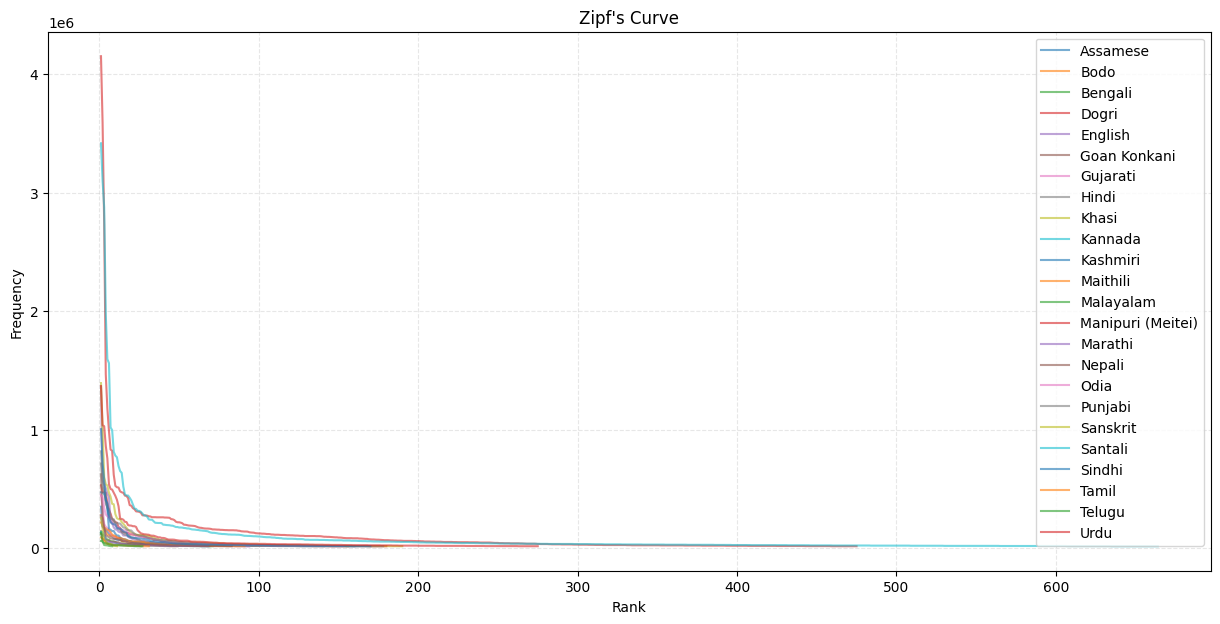

In [20]:
plt.figure(figsize=(15, 7))

for language, word_freq in stopword_removed.items():
    sorted_freq = sorted(word_freq.values(), reverse=True)[:]

    ranks = range(1, len(sorted_freq) + 1)

    plt.plot(
        ranks,
        sorted_freq,
        label=language,
        alpha=0.6
    )

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Curve")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.show()

# making n grams

In [21]:
data={"D:/LLM/LAB 1/Dataset/train_combined_ngram.csv":train_df,"D:/LLM/LAB 1/Dataset/test_combined_ngram.csv":test_df,"D:/LLM/LAB 1/Dataset/val_combined_ngram.csv":val_df,"D:/LLM/LAB 1/Dataset/full_data_ngram.csv":full_df}

In [22]:
def make_ngrams(text):
    tokens=''
    for n in [2,3,4]:
        for i in range(len(text)-n+1):
            token=''
            for j in range(i,i+n):
                token=token+text[j]
            tokens=tokens+" "+token

    return tokens

In [23]:
for path,df in data.items():
    new_df=df.copy()
    new_df["text"]=new_df["text"].apply(make_ngrams)

    new_df.to_csv(path,index=False)


In [24]:
train_ngram_df = pd.read_csv("D:/LLM/LAB 1/Dataset/train_combined_ngram.csv")
test_ngram_df = pd.read_csv("D:/LLM/LAB 1/Dataset/test_combined_ngram.csv")
val_ngram_df = pd.read_csv("D:/LLM/LAB 1/Dataset/val_combined_ngram.csv")
full_ngram_df = pd.read_csv("D:/LLM/LAB 1/Dataset/full_data_ngram.csv")


# vocab and frequency analysis (ngram level)

In [25]:
globle_vocab_ngram=set()
language_vocab_ngram={}
language_vocab_freq_ngram={}
globle_vocab_freq_ngram={}

In [26]:
def vocab_ngram(text):
    tokens=set()

    for line in text:
        words=str(line).lower().split()

        for n in [2,3,4]:
            for w in words:
                for i in range(0,len(w)-n+1):
                    token=w[i:i+n]
                    tokens.add((token))

    return tokens


def build_frequency_ngram(text,freq=None):

    if freq==None:
        freq={}

    for line in text:

        words=str(line).lower().split()

        for n in [2,3,4]:
            for w in words:
                for i in range(0,len(w)-n+1):
                    token=w[i:i+n]
                    freq[token]=freq.get(token,0)+1

    return freq



In [27]:
for filename, language in language_mapping.items():

    v=vocab_ngram(full_ngram_df.loc[full_ngram_df["language"]==language,'text'])
    globle_vocab_ngram.update(v)
    language_vocab_ngram[language]=v
    
    globle_vocab_freq_ngram=build_frequency_ngram(full_ngram_df.loc[full_ngram_df["language"]==language,'text'],globle_vocab_freq_ngram)
    language_vocab_freq_ngram[language]=build_frequency_ngram(full_ngram_df.loc[full_ngram_df["language"]==language,'text'])

In [28]:
language_vocab_size_ngram={}

for language in language_vocab_ngram:
    language_vocab_size_ngram[language]=len(language_vocab_ngram[language])

{'Assamese': 29711, 'Bodo': 23546, 'Bengali': 21146, 'Dogri': 22996, 'English': 18974, 'Goan Konkani': 24763, 'Gujarati': 24415, 'Hindi': 18552, 'Khasi': 19901, 'Kannada': 25963, 'Kashmiri': 20032, 'Maithili': 26499, 'Malayalam': 24182, 'Manipuri (Meitei)': 44407, 'Marathi': 22845, 'Nepali': 22629, 'Odia': 18214, 'Punjabi': 22167, 'Sanskrit': 29489, 'Santali': 48332, 'Sindhi': 18581, 'Tamil': 18914, 'Telugu': 21335, 'Urdu': 22110}


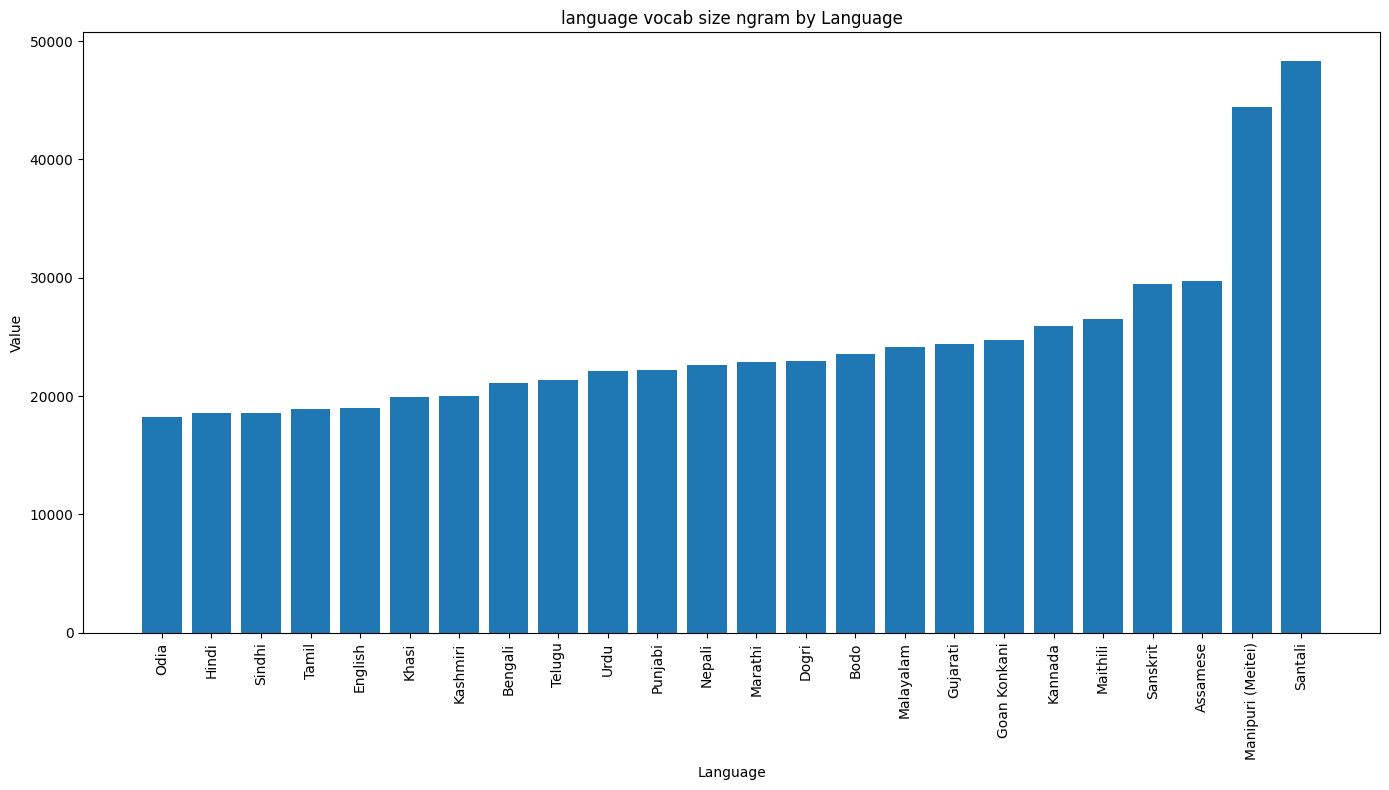

In [29]:
language_vocab_size_ngram={}

for language in language_vocab_ngram:
    language_vocab_size_ngram[language]=len(language_vocab_freq_ngram[language])

print(language_vocab_size_ngram)

data_sorted = dict(sorted(language_vocab_size_ngram.items(), key=lambda x: x[1]))
plt.figure(figsize=(14, 8))

plt.bar(data_sorted.keys(), data_sorted.values())

plt.xlabel("Language")
plt.ylabel("Value")
plt.title("language vocab size ngram by Language")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

{'Assamese': 891299, 'Bodo': 846291, 'Bengali': 510360, 'Dogri': 659563, 'English': 722918, 'Goan Konkani': 467743, 'Gujarati': 592900, 'Hindi': 492999, 'Khasi': 934971, 'Kannada': 693137, 'Kashmiri': 458638, 'Maithili': 471607, 'Malayalam': 703238, 'Manipuri (Meitei)': 2664871, 'Marathi': 560759, 'Nepali': 603540, 'Odia': 805215, 'Punjabi': 619244, 'Sanskrit': 395678, 'Santali': 2806869, 'Sindhi': 516296, 'Tamil': 744172, 'Telugu': 538011, 'Urdu': 823974}


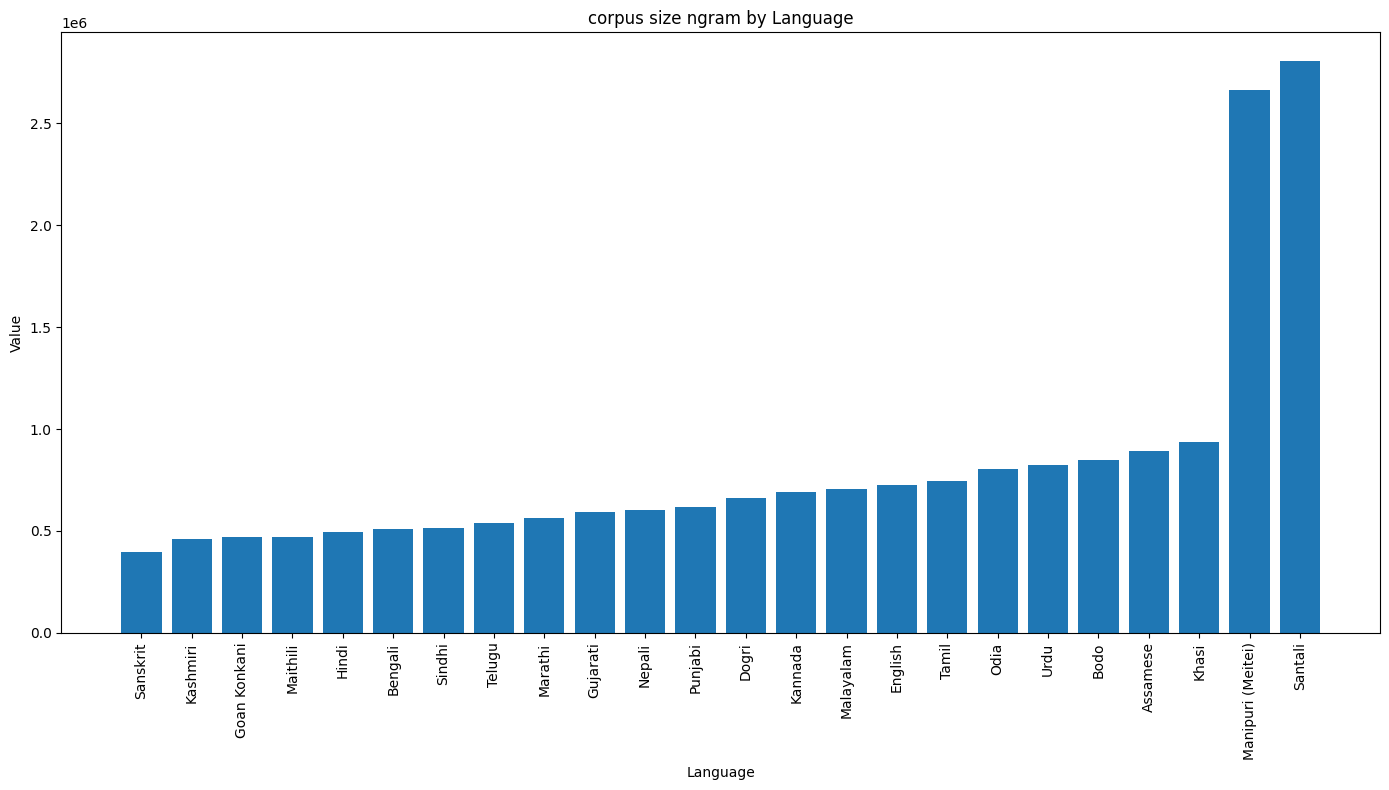

In [30]:
corpus_size_ngram={}

for language,freqs in language_vocab_freq_ngram.items():
    corpus_size_ngram[language]=sum(freqs.values())

print(corpus_size_ngram)

data_sorted = dict(sorted(corpus_size_ngram.items(), key=lambda x: x[1]))
plt.figure(figsize=(14, 8))

plt.bar(data_sorted.keys(), data_sorted.values())

plt.xlabel("Language")
plt.ylabel("Value")
plt.title("corpus size ngram by Language")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

{'Assamese': 0.045650769531065734, 'Bodo': 0.04334553881157182, 'Bengali': 0.02613974293460972, 'Dogri': 0.03378165857273295, 'English': 0.037026590412262306, 'Goan Konkani': 0.023956975036176727, 'Gujarati': 0.03036729678252626, 'Hindi': 0.025250543003016806, 'Khasi': 0.04788757267676735, 'Kannada': 0.035501259891971504, 'Kashmiri': 0.02349063292586318, 'Maithili': 0.02415488233043829, 'Malayalam': 0.036018615373166134, 'Manipuri (Meitei)': 0.13649001272414832, 'Marathi': 0.028721091206734092, 'Nepali': 0.030912258897159553, 'Odia': 0.04124169822692171, 'Punjabi': 0.031716590198682226, 'Sanskrit': 0.020265932292657152, 'Santali': 0.14376290091528537, 'Sindhi': 0.026443774430141977, 'Tamil': 0.03811518296718862, 'Telugu': 0.027555978595486145, 'Urdu': 0.04220250126342603}


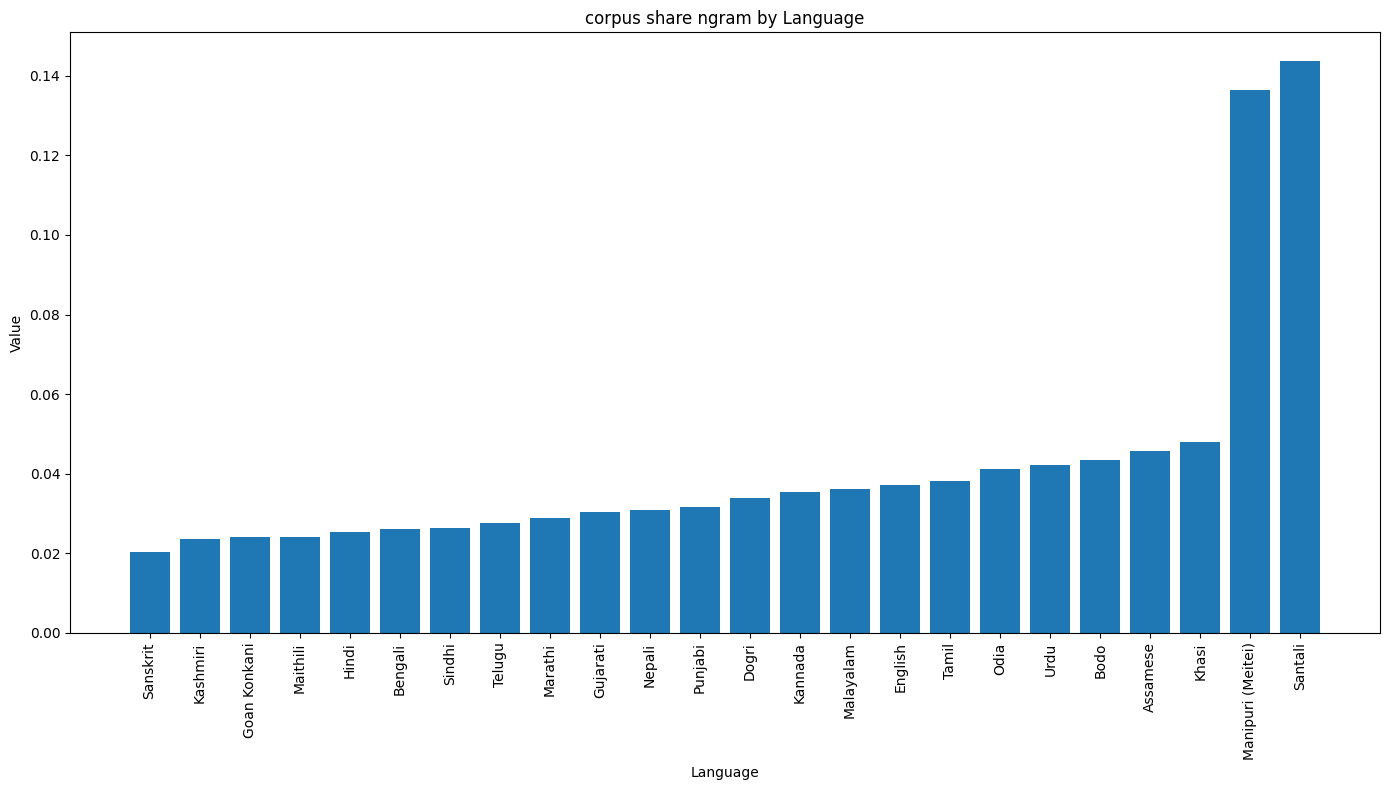

In [31]:
corpus_share_ngram={}
total=sum(corpus_size_ngram.values())

for language,size in corpus_size_ngram.items():
    corpus_share_ngram[language]=size/total

print(corpus_share_ngram)

data_sorted = dict(sorted(corpus_share_ngram.items(), key=lambda x: x[1]))
plt.figure(figsize=(14, 8))

plt.bar(data_sorted.keys(), data_sorted.values())

plt.xlabel("Language")
plt.ylabel("Value")
plt.title("corpus share ngram by Language")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [32]:
with open("D:/LLM/LAB 1/Dataset/vocab/metadata/globle_vocab_ngram.pkl", "wb") as file:
    pickle.dump(globle_vocab_ngram, file)

with open("D:/LLM/LAB 1/Dataset/vocab/metadata/language_vocab_ngram.pkl", "wb") as file:
    pickle.dump(language_vocab_ngram, file)

with open("D:/LLM/LAB 1/Dataset/vocab/metadata/language_vocab_freq_ngram.pkl", "wb") as file:
    pickle.dump(language_vocab_freq_ngram, file)

with open("D:/LLM/LAB 1/Dataset/vocab/metadata/globle_vocab_freq_ngram.pkl", "wb") as file:
    pickle.dump(globle_vocab_freq_ngram, file)

with open("D:/LLM/LAB 1/Dataset/vocab/metadata/language_vocab_size.pkl", "wb") as file:
    pickle.dump(language_vocab_size_ngram, file)


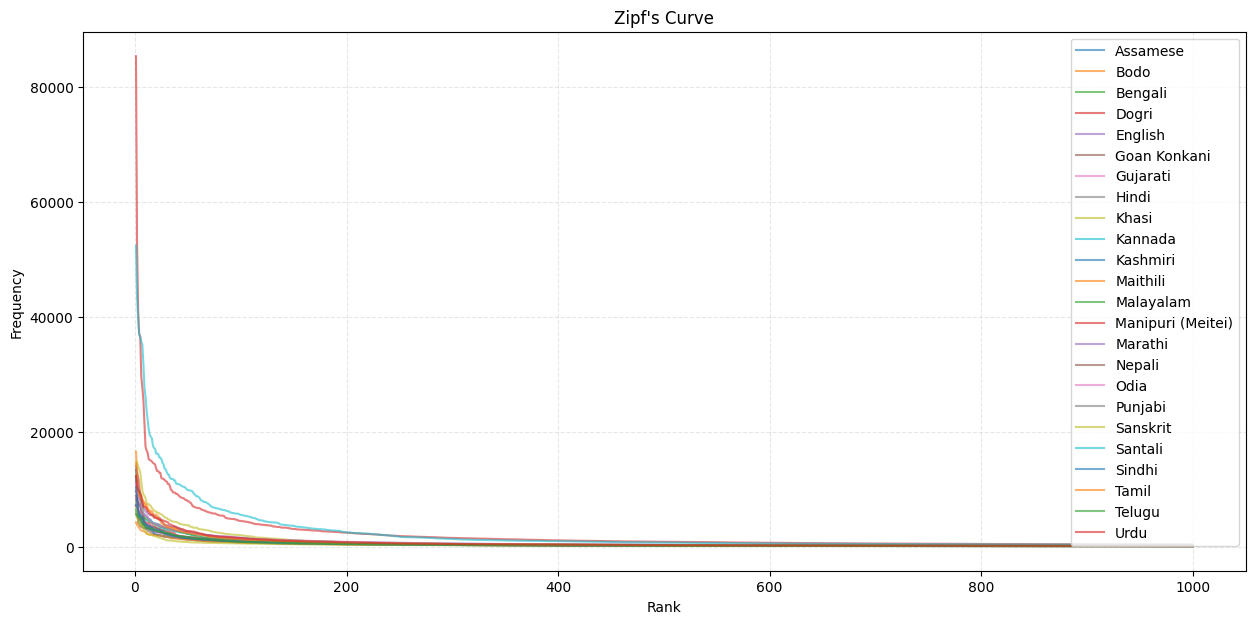

In [90]:
plt.figure(figsize=(15, 7))

for language, word_freq in language_vocab_freq_ngram.items():
    sorted_freq = sorted(word_freq.values(), reverse=True)[:1000]

    ranks = range(1, len(sorted_freq) + 1)

    plt.plot(
        ranks,
        sorted_freq,
        label=language,
        alpha=0.6
    )

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Curve")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.show()

# working with stop words ( ngram )

In [34]:
def top_k(freq, k=100):
    return sorted(freq.items(), key=lambda x: (-x[1], x[0]))[:k]


def remove_stopwords(freq, threshold, direction="above"):


    # Two thresholds: keep values between the two thresholds
    if isinstance(threshold, (tuple, list)):

        low, high = sorted(threshold)

        # Both thresholds are percentages
        if (
            isinstance(low, float) and 0 <= low <= 1
            and isinstance(high, float) and 0 < high <= 1
        ):
            sorted_words = sorted(
                freq.items(),
                key=lambda x: (-x[1], x[0])
            )

            n = len(sorted_words)

            start = int(n * low)
            end = int(n * high)

            # Keep the entries between the two percentage positions
            cleaned = dict(sorted_words[start:end])

            return cleaned, (low, high)

        # Both thresholds are frequency values
        if isinstance(low, int) and isinstance(high, int):
            cleaned = {
                w: c for w, c in freq.items()
                if low < c < high
            }

            return cleaned, (low, high)


    if isinstance(threshold, float) and 0 < threshold <= 1:
        sorted_words = sorted(
            freq.items(),
            key=lambda x: (-x[1], x[0])
        )

        n = int(len(sorted_words) * threshold)

        if direction == "above":
            # Keep top threshold %
            cleaned = dict(sorted_words[:n])
        else:
            # Keep bottom threshold %
            cleaned = dict(sorted_words[-n:] if n > 0 else [])

        return cleaned, threshold


    threshold = int(threshold)

    if direction == "above":

        cleaned = {
            w: c for w, c in freq.items()
            if c > threshold
        }
    else:

        cleaned = {
            w: c for w, c in freq.items()
            if c < threshold
        }

    return cleaned, threshold


In [85]:
stopword_removed_ngram={}
threshold=0.5

for lang,freq in language_vocab_freq_ngram.items():
    stopword_removed_ngram[lang],_=remove_stopwords(freq,threshold,"above")


In [86]:
with open("D:/LLM/LAB 1/Dataset/vocab/top_05.pkl", "wb") as file:
    pickle.dump(stopword_removed_ngram, file)

In [87]:
total=0
for l in stopword_removed_ngram:
    total=total+len(stopword_removed_ngram[l])

total

294845

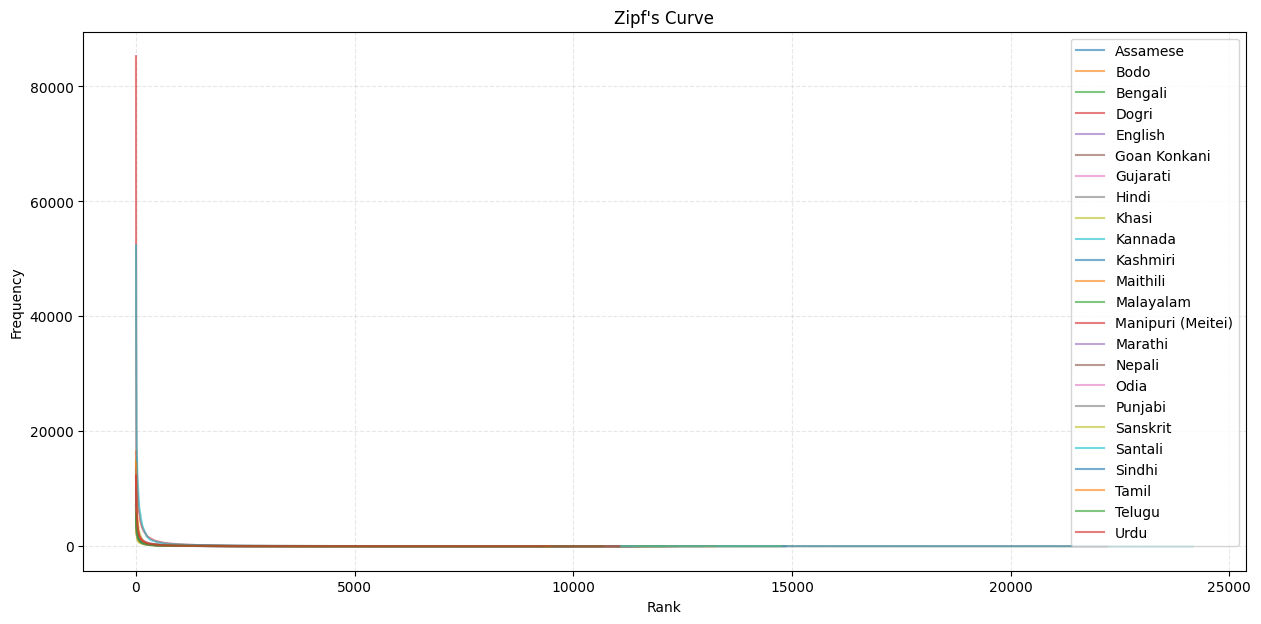

In [89]:
plt.figure(figsize=(15, 7))
total_f=0
for language, word_freq in stopword_removed_ngram.items():

    sorted_freq = sorted(word_freq.values(), reverse=True)[:]

    ranks = range(1, len(sorted_freq) + 1)

    plt.plot(
        ranks,
        sorted_freq,
        label=language,
        alpha=0.6
    )

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Curve")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.show()